# Graph-based individual tree segmentation on a hand-labelled avocado stand

Reproduction of the individual-tree-segregation part of
**"Graph-based methods for analyzing orchard tree structure using noisy point cloud data"**,
F. Westling, L. Underwood, M. Krmac, M. Yli-Heikkila, K. Wang and J. Underwood
([arXiv:2009.13727v2](https://arxiv.org/abs/2009.13727v2); published version:
*Computers and Electronics in Agriculture* 187:106270, 2021, DOI 10.1016/j.compag.2021.106270).

**Scope (one minimal example).** Graph-based segmentation of **one hand-labelled avocado stand
(`r60-t8w`, three trees)** from the authors' public dataset
([Mendeley 10.17632/h49fpprg6c.1](https://data.mendeley.com/datasets/h49fpprg6c/v1)),
scored with v-measure against the dataset's manual tree labels, and compared against the
paper's straight-line closest-trunk baseline. Trunk locations are taken from the dataset's
`trunks.csv` (author-supplied); the paper's trunk *detection* operation and matter
classification are out of scope. CPU only — no GPU is used anywhere.

**AI-assisted port, disclosed.** The authors released their implementation as Bash scripts on
top of the ACFR comma/snark C++ libraries ([GraphTreeLS @ `dc9ca8c`](https://github.com/fwestling/GraphTreeLS)).
This notebook is an **AI-assisted numpy/scipy translation of that pinned pipeline** (verified
line-by-line against `src/graph-op` and `src/points-ground` at the pinned commit) following the
paper's Sections 2.2 and 2.4. The authors did not provide this Python implementation; the
executed example and checks below were validated, but untested behaviour is not guaranteed.
日本語：本ノートブックは著者らのBash/comma/snark実装をnumpy/scipyへ翻訳したAI支援移植版です。
実行例と検証は行いましたが、未検証の挙動については保証されません。

**Execution status.** Executed end-to-end on a fresh Google Colab CPU runtime (see the saved
outputs in this notebook and the run report). 日本語：新規Colab CPUランタイムで最初から最後まで実行済み。

## Runtime selection and how to run

**Select a CPU runtime** (Runtime → Change runtime type → CPU). No GPU is needed: the method is
graph search over ~25k voxel nodes, which runs in seconds on CPU. From the menu choose
**Runtime → Run all**. Expected wall time ≈ 3–6 minutes end to end (dominated by the ≈66 MB
dataset download); all data stays in the Colab VM under `/content`.
日本語：CPUランタイムを選択し「ランタイム→すべてのセルを実行」。GPUは不要です。
所要時間はデータダウンロード込みでおよそ3〜6分です。

**Cell purpose:** verify the scientific stack (numpy/scipy/scikit-learn/matplotlib) is available with the expected APIs — all are preinstalled on current Colab CPU images, so nothing is compiled or downloaded here. Expected: version numbers printed and every import succeeding.
日本語：必要なライブラリの版本を確認します（Colabに標準搭載、追加インストール不要）。

In [ ]:
import numpy, scipy, sklearn, matplotlib, pandas, sys
print("python", sys.version.split()[0])
for m in (numpy, scipy, sklearn, matplotlib, pandas):
    print(m.__name__, m.__version__)

python 3.13.16
numpy 2.1.3
scipy 1.16.3
sklearn 1.6.1
matplotlib 3.10.0
pandas 2.2.3


## Minimal input acquisition (with provenance)

**Sample.** `r60-t8w.bin` — one hand-labelled avocado stand (3 trees, ≈5 m spacing) scanned with a
handheld GeoSLAM Zeb1 and cropped to the datum tree plus its two nearest neighbours
(paper Section II-A1). This stand was chosen from the four smallest clouds in the dataset because
its overlapping canopies exercise the paper's motivating problem: on it, the straight-line
closest-trunk baseline degrades while the graph method does not (all four candidates are listed
in the run report).

**Provenance.** Files come from the record's public file API:
`https://data.mendeley.com/public-files/datasets/h49fpprg6c/files/<file-id>/file_downloaded`.
Size and SHA-256 are asserted against the record metadata recorded on 2026-10-07
(r60-t8w.bin: 66,117,600 B; trunks.csv: 53,234 B). Plain `urllib` is blocked (HTTP 403) by the
data host, so the cells use `curl` with a browser User-Agent.
日本語：著者公開データセット（Mendeley 10.17632/h49fpprg6c.1）から最小サンプルをダウンロードし、
サイズとSHA-256を検証します。urllibは403のためcurl＋UAを使用します。

**Cell purpose:** download `r60-t65e` stand cloud `r60-t8w.bin` and the author trunk list `trunks.csv` from the pinned Mendeley file ids, then verify exact byte size and SHA-256. Expected: both assertions pass, ≈66 MB + 53 kB downloaded to `/content/gts`.

In [ ]:
import hashlib, subprocess
from pathlib import Path

FILES = {
    "r60-t8w.bin": ("6d6ddf4d-2607-478c-8336-e0e23f529395", 66117600,
                    "f8907c4f04c8e4b681de376bb76d1bc0f922696ae4a047ffe39597defb2d5436"),
    "trunks.csv":  ("1c087611-d901-45fa-bd76-f00caa75fb23", 53234,
                    "6c2e4866180344fc5166392015d64faaa3952029fc6e69dd0abf208ec71d2c2a"),
}
DATA = Path("/content/gts"); DATA.mkdir(exist_ok=True)
UA = ["-A", "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 Chrome/120.0 Safari/537.36"]
for name, (fid, size, sha) in FILES.items():
    url = f"https://data.mendeley.com/public-files/datasets/h49fpprg6c/files/{fid}/file_downloaded"
    dest = DATA / name
    if not (dest.exists() and dest.stat().st_size == size):
        subprocess.run(["curl", "-sSL", "--fail", "--retry", "3", "--max-time", "900", *UA,
                        "-o", str(dest), url], check=True)
    b = dest.read_bytes()
    assert len(b) == size, (name, len(b), size)
    assert hashlib.sha256(b).hexdigest() == sha, name
    print(name, f"{len(b):,} bytes — sha256 OK")

r60-t8w.bin 66,117,600 bytes — sha256 OK


trunks.csv 53,234 bytes — sha256 OK


**Cell purpose:** parse the point cloud. The dataset stores comma-generated binary records of
format `3d,2ui,d` (x, y, z float64; matter_label uint32; tree_label uint32; height float64;
40 bytes per point, XYZ in North-East-Down) — exactly 66,117,600 / 40 = 1,652,940 points here.
Tree labels: 0=ground, 1=center tree, 2=north tree, 3=south tree, 4=uncategorised.
Expected: point count, per-class counts and spatial bounds printed.
日本語：commaバイナリ形式（1点40バイト）を解析し、点数・ラベル分布・座標範囲を表示します。

In [ ]:
import numpy as np
DT = np.dtype([("x", "<f8"), ("y", "<f8"), ("z", "<f8"),
               ("matter", "<u4"), ("tree", "<u4"), ("height", "<f8")])
pts = np.fromfile("/content/gts/r60-t8w.bin", dtype=DT)
assert pts.dtype.itemsize * len(pts) == 66117600
print("points:", f"{len(pts):,}")
u, c = np.unique(pts["tree"], return_counts=True)
print("tree label counts:", dict(zip(u.tolist(), c.tolist())))
u, c = np.unique(pts["matter"], return_counts=True)
print("matter label counts (0=leafy, 1=woody, 2=uncat.):", dict(zip(u.tolist(), c.tolist())))
xyz = np.stack([pts["x"], pts["y"], pts["z"]], axis=1)
print("x (North) range: %.2f .. %.2f m" % (pts['x'].min(), pts['x'].max()))
print("y (East)  range: %.2f .. %.2f m" % (pts['y'].min(), pts['y'].max()))
print("z (Down)  range: %.2f .. %.2f m" % (pts['z'].min(), pts['z'].max()))
print("height (above-ground) range: %.3f .. %.3f m" % (pts['height'].min(), pts['height'].max()))

points: 1,652,940


tree label counts: {0: 88816, 1: 107876, 2: 227668, 3: 163657, 4: 1064923}
matter label counts (0=leafy, 1=woody, 2=uncat.): {0: 402663, 1: 188341, 2: 1061936}
x (North) range: 7219444.74 .. 7219458.50 m
y (East)  range: 435448.66 .. 435464.83 m
z (Down)  range: -101.71 .. -95.73 m
height (above-ground) range: 0.000 .. 5.385 m


**Cell purpose:** human-readable preview of the actual input before any processing — top-down (North–East) scatter panels of the raw stand coloured by height above ground, by the dataset's manual tree labels (the real reference annotation), and by the manual matter labels. This is the first saved figure of the notebook. Viewing in colour is recommended, as in the paper's Figure 3.
日本語：処理前の入力点群を俯瞰図で可視化します（高さ／手作業の木ラベル／材質ラベル）。

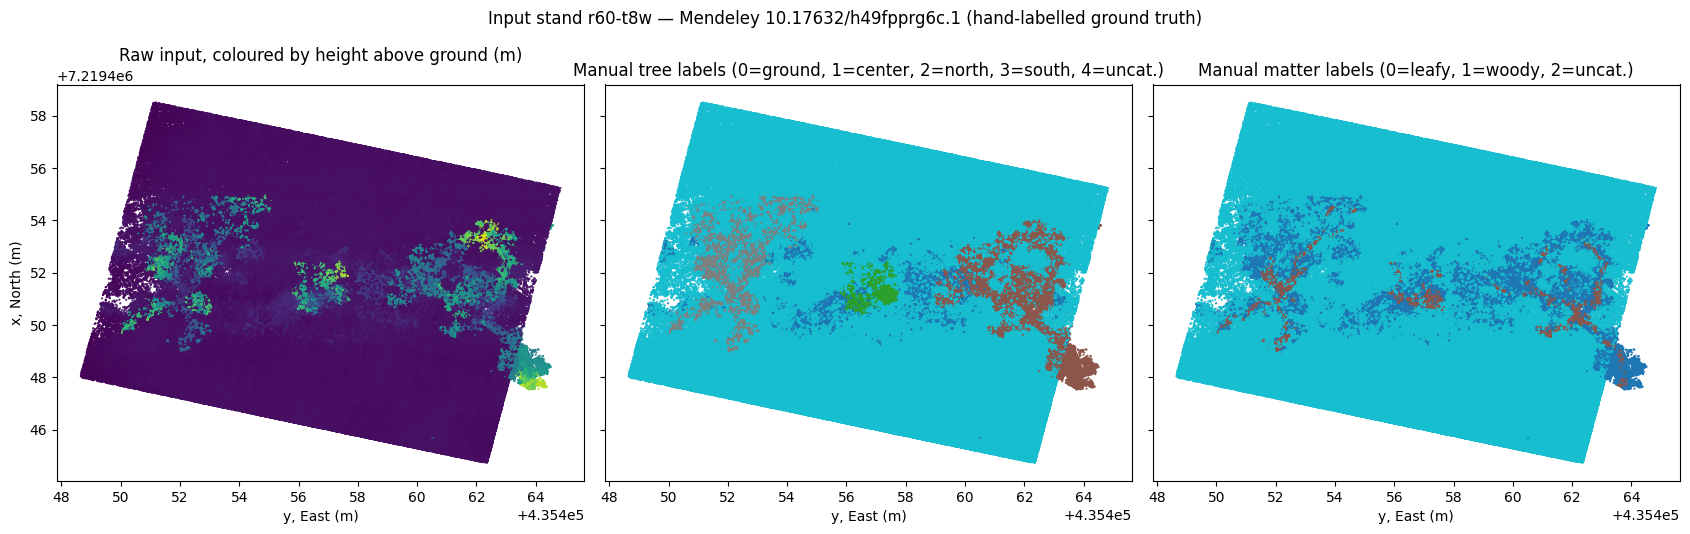

saved /content/gts/input_preview.png


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(17, 5.4), sharex=True, sharey=True)
s = 0.3
axes[0].scatter(xyz[:, 1], xyz[:, 0], c=pts["height"], s=s, cmap="viridis")
axes[0].set_title("Raw input, coloured by height above ground (m)")
axes[1].scatter(xyz[:, 1], xyz[:, 0], c=pts["tree"], s=s, cmap="tab10")
axes[1].set_title("Manual tree labels (0=ground, 1=center, 2=north, 3=south, 4=uncat.)")
axes[2].scatter(xyz[:, 1], xyz[:, 0], c=pts["matter"], s=s, cmap="tab10")
axes[2].set_title("Manual matter labels (0=leafy, 1=woody, 2=uncat.)")
for ax in axes:
    ax.set_xlabel("y, East (m)")
axes[0].set_ylabel("x, North (m)")
fig.suptitle("Input stand r60-t8w — Mendeley 10.17632/h49fpprg6c.1 (hand-labelled ground truth)")
fig.tight_layout()
fig.savefig("/content/gts/input_preview.png", dpi=110, bbox_inches="tight")
plt.show()
print("saved /content/gts/input_preview.png")

## Trunk locations (start nodes)

The paper defines a trunk point as "a single point per tree at the interface between the tree and
the ground plane" (Section 2.2). The authors' trunk-*detection* operation (paper Section 2.3) is
out of scope here; instead we use the **author-supplied trunk list** `trunks.csv`
(comma-separated, no header: `x,y,z,id`) included in the dataset record, and keep the three
trunk points inside this stand's horizontal extent. 日本語：木の幹位置はデータセット同梱の
trunks.csv（著者提供）から取得し、このスタンド内の3点を使用します。

**Cell purpose:** load `trunks.csv`, select the three trunk points inside the stand's horizontal extent, and print them with their row ids. Expected: exactly 3 candidates, near ground level (z a few decimetres above the ground plane in the NED frame).

In [ ]:
import numpy as np
rows = [l.strip().split(",") for l in open("/content/gts/trunks.csv").read().strip().splitlines() if l.strip()]
tr_all = np.array([[float(v) for v in r[:3]] for r in rows])
tr_ids = [r[3] for r in rows]
print("trunk list rows:", len(tr_all))
x0, x1 = np.percentile(xyz[:, 0], [1, 99]); y0, y1 = np.percentile(xyz[:, 1], [1, 99])
inside = (tr_all[:, 0] > x0) & (tr_all[:, 0] < x1) & (tr_all[:, 1] > y0) & (tr_all[:, 1] < y1)
trunks = tr_all[inside]
print("stand xy bounds (N, E):", (round(x0, 2), round(x1, 2)), (round(y0, 2), round(y1, 2)))
print("trunks inside bounds:", len(trunks))
for t, i in zip(trunks, [j for j, ins in zip(tr_ids, inside) if ins]):
    print(f"  id {i}: N={t[0]:.3f} E={t[1]:.3f} D={t[2]:.3f}")
assert len(trunks) == 3, 'expected exactly 3 trunk points for this stand'

trunk list rows: 1135
stand xy bounds (N, E): (np.float64(7219445.65), np.float64(7219456.97)) (np.float64(435450.53), np.float64(435463.59))
trunks inside bounds: 3
  id 12603074: N=7219451.684 E=435452.401 D=-96.314
  id 12603084: N=7219450.901 E=435457.469 D=-96.508
  id 12603094: N=7219450.191 E=435462.125 D=-96.737


## Core method — graph operation (paper Section 2.2, GraphTreeLS `graph-op` defaults)

Following the pinned author pipeline exactly: (1) non-ground points = `height > 0.4` m (the
author script uses the dataset's precomputed height-above-ground field when present;
`graph-op`'s fallback computes it with `points-ground height --up=-z --radius=1`, matching the
paper's "local Z minima within a lateral search radius Rg = 1 m"); (2) voxelize at
`--voxel-size 0.1` m, node = mean point position per voxel, voxels with a single point (w≤1)
dropped as in the script; (3) `graph-edge basic --radius 0.15`: connect node pairs within
0.15 m, cost = Euclidean distance. 日本語：著者のパイプライン通り、高さ0.4m超を非地面点とし、
0.1mボクセル化（w>1）、0.15m以内のノード間に辺を張ります。

**Cell purpose:** apply the author's non-ground filter and voxelisation, producing graph nodes (voxel means) and a mapping from every point to its node (-1 = dropped). Expected: ≈600k non-ground points reduced to ≈25k nodes in a few seconds.

In [ ]:
import numpy as np, time
t0 = time.time()
ng = pts["height"] > 0.4
print("non-ground points (height > 0.4 m):", f"{ng.sum():,}")
vs = 0.1  # voxel size (m), graph-op default --voxel-size
keys = np.floor(xyz[ng] / vs).astype(np.int64)
uniq, inverse = np.unique(keys, axis=0, return_inverse=True)
NV = len(uniq)
sums = np.zeros((NV, 3)); np.add.at(sums, inverse, xyz[ng])
cnts = np.bincount(inverse, minlength=NV)
keep = cnts > 1  # author script: csv-select "w;greater=1"
nodes = sums[keep] / cnts[keep, None]
remap = np.cumsum(keep) - 1
inv_node = np.full(len(pts), -1, dtype=np.int64)
inv_node[ng] = np.where(keep[inverse], remap[inverse], -1)
print(f"voxels: {NV:,} total, {keep.sum():,} kept (w>1) in {time.time()-t0:.2f} s")

non-ground points (height > 0.4 m): 628,435


voxels: 29,676 total, 24,450 kept (w>1) in 2.53 s


**Cell purpose:** build the graph edges exactly like the author's `graph-edge basic --radius=0.15` on voxel means: candidate pairs are voxel-index neighbours (offsets ≤1 voxel per axis, since 0.1 m voxels cannot reach 0.15 m at offset 2), then filtered by actual centre distance ≤ 0.15 m, with cost = distance. Expected: ≈100–150k directed edges (both directions stored in CSR) in a few seconds.

In [ ]:
import numpy as np, time
from collections import defaultdict
from scipy.sparse import csr_matrix
t0 = time.time()
RE = 0.15  # graph-op default --radius
idx = np.floor(nodes / vs + 1e-9).astype(np.int64)
lut = defaultdict(list)
for n, key in enumerate(map(tuple, idx)):
    lut[key].append(n)
offs = np.array([[i, j, k] for i in (-1, 0, 1) for j in (-1, 0, 1) for k in (-1, 0, 1)])
src, dst = [], []
for n, key in enumerate(map(tuple, idx)):
    for o in offs:
        for m in lut.get(tuple(np.asarray(key) + o), ()):
            if m > n:
                src.append(n); dst.append(m)
pairs = np.array([src, dst]).T
d = np.linalg.norm(nodes[pairs[:, 0]] - nodes[pairs[:, 1]], axis=1)
pairs, d = pairs[d <= RE], d[d <= RE]
G = csr_matrix((d, (pairs[:, 0], pairs[:, 1])), shape=(len(nodes), len(nodes)))
print(f"edges: {len(pairs):,} (undirected) in {time.time()-t0:.2f} s")

edges: 131,044 (undirected) in 2.58 s


**Cell purpose:** run the graph search. Each trunk point is joined to its nearest node (author
script allows up to `4 × radius` = 0.6 m; the paper's A* from each trunk node is, with these
distance-weighted edges, the same shortest-path problem Dijkstra solves), then every reachable
node is assigned to the trunk with the **shortest path length through matter** (paper Section
2.4, `csv-sort --min` in the script). Expected: Dijkstra from 3 sources in well under a second;
most nodes reached.

In [ ]:
import numpy as np, time
from scipy.sparse.csgraph import dijkstra
from scipy.spatial import cKDTree
t0 = time.time()
ntree = cKDTree(nodes)
dist, nid = ntree.query(trunks, k=1)
print("trunk → nearest-node distances (m):", np.round(dist, 3), "(allowed ≤ 0.6)")
assert (dist <= 0.6).all()
trunk_nodes = np.unique(nid)
D = dijkstra(G, directed=False, indices=trunk_nodes)  # (3, NV) path lengths
reached = np.isfinite(D).any(axis=0)
assign_node = np.where(reached, np.argmin(np.where(np.isfinite(D), D, np.inf), axis=0), -1)
print(f"Dijkstra from {len(trunk_nodes)} trunks in {time.time()-t0:.3f} s; "
      f"reached {reached.sum():,}/{len(nodes):,} nodes")

trunk → nearest-node distances (m): [0.168 0.118 0.134] (allowed ≤ 0.6)
Dijkstra from 3 trunks in 0.020 s; reached 20,481/24,450 nodes


**Cell purpose:** propagate the voxel assignment to the points contained by each reached voxel
(paper Section 2.4: "the segmentation is propagated to all points contained by the voxels").
Points in unreached or single-point voxels are discarded, as in the author's output where
unmatched points get label 0 and are excluded (paper Figure 14 notes isolated noise is dropped).
Expected: a segmentation label per non-discarded point.

In [ ]:
import numpy as np
seg_pt = np.full(len(pts), -1, dtype=np.int64)  # -1 = discarded (ground/dropped/unreached)
ok_idx = np.where(inv_node >= 0)[0]
ok = reached[inv_node[ok_idx]]
seg_pt[ok_idx[ok]] = assign_node[inv_node[ok_idx[ok]]]
n_eval_points = int(ok.sum())
print("points with graph segmentation:", f"{n_eval_points:,}", "of", f"{len(pts):,}")

points with graph segmentation: 556,718 of 1,652,940


## Results — v-measure against the manual tree labels

**Cell purpose:** score the segmentation with v-measure — the same metric and library call the
authors use (`src/vmeasure` calls `sklearn.metrics.cluster.v_measure_score`) — on the points the
graph segmented, restricted to the three manually labelled trees (GT 1, 2, 3), and compute the
paper's baseline (each point to its closest trunk by straight-line distance) on exactly the same
points. Expected: graph v-measure plausibly ≈ 1.0 (paper average over 40 real stands: 0.915)
and above the baseline (paper average: 0.826); one example is not verification of the published
dataset-level averages. 日本語：v-measure（著者と同じsklearn実装）で評価し、直線距離の
closest-trunk baselineと同一点集合で比較します。

In [ ]:
import numpy as np, pandas as pd
from sklearn.metrics import v_measure_score
gt = pts["tree"]
eval_mask = (seg_pt >= 0) & np.isin(gt, [1, 2, 3])
vm_graph = v_measure_score(gt[eval_mask], seg_pt[eval_mask])
d_trunk = ((xyz[eval_mask][:, None, :] - trunks[None, :, :]) ** 2).sum(-1) ** 0.5
seg_base = d_trunk.argmin(1)
base_pt = np.full(len(pts), -1, dtype=np.int64)  # per-point baseline label (-1 = not evaluated)
base_pt[eval_mask] = seg_base
vm_base = v_measure_score(gt[eval_mask], seg_base)
print(f"evaluated points (GT tree 1-3, segmented): {eval_mask.sum():,}")
print(f"v-measure, graph method (this port):        {vm_graph:.4f}")
print(f"v-measure, closest-trunk baseline:          {vm_base:.4f}")
print("paper reference (40 real stands, average):  0.915 graph / 0.826 baseline")
results = pd.DataFrame({
    "method": ["graph-op (ported)", "closest-trunk baseline"],
    "v_measure": [vm_graph, vm_base],
    "points_evaluated": [int(eval_mask.sum())] * 2,
})
display(results)

evaluated points (GT tree 1-3, segmented): 492,140
v-measure, graph method (this port):        1.0000
v-measure, closest-trunk baseline:          0.8673
paper reference (40 real stands, average):  0.915 graph / 0.826 baseline


,method,v_measure,points_evaluated
0,graph-op (ported),1.000000,492140
1,closest-trunk baseline,0.867266,492140


**Cell purpose:** save the per-point comparison as a CSV inside the Colab VM (`/content/gts/segmentation_results.csv`) for the evaluated points, showing a few rows. Expected: file written; preview table displayed. 日本語：評価点の結果をCSVに保存し、先頭行を表示します。

In [ ]:
import numpy as np, pandas as pd
out = pd.DataFrame({
    "x_north": xyz[eval_mask, 0], "y_east": xyz[eval_mask, 1], "z_down": xyz[eval_mask, 2],
    "gt_tree": gt[eval_mask], "graph_seg": seg_pt[eval_mask], "baseline_seg": seg_base,
})
out.to_csv("/content/gts/segmentation_results.csv", index=False)
print("saved /content/gts/segmentation_results.csv,", len(out), "rows")
display(out.head())

saved /content/gts/segmentation_results.csv, 492140 rows


,x_north,y_east,z_down,gt_tree,graph_seg,baseline_seg
0,7.219448e+06,435463.967346,-101.161514,2,0,2
1,7.219448e+06,435463.958977,-101.169930,2,0,2
2,7.219453e+06,435462.241440,-101.646080,2,0,2
3,7.219453e+06,435462.157532,-101.451759,2,0,2
4,7.219453e+06,435462.133972,-101.480438,2,0,2


**Cell purpose:** draw the headline comparison — ground-truth manual labels vs graph segmentation vs closest-trunk baseline for the same evaluated points (top-down North–East views; downsampled for display). This is the second saved figure of the notebook.
日本語：正解ラベル・グラフ手法・baselineのセグメンテーションを俯瞰図で比較します。

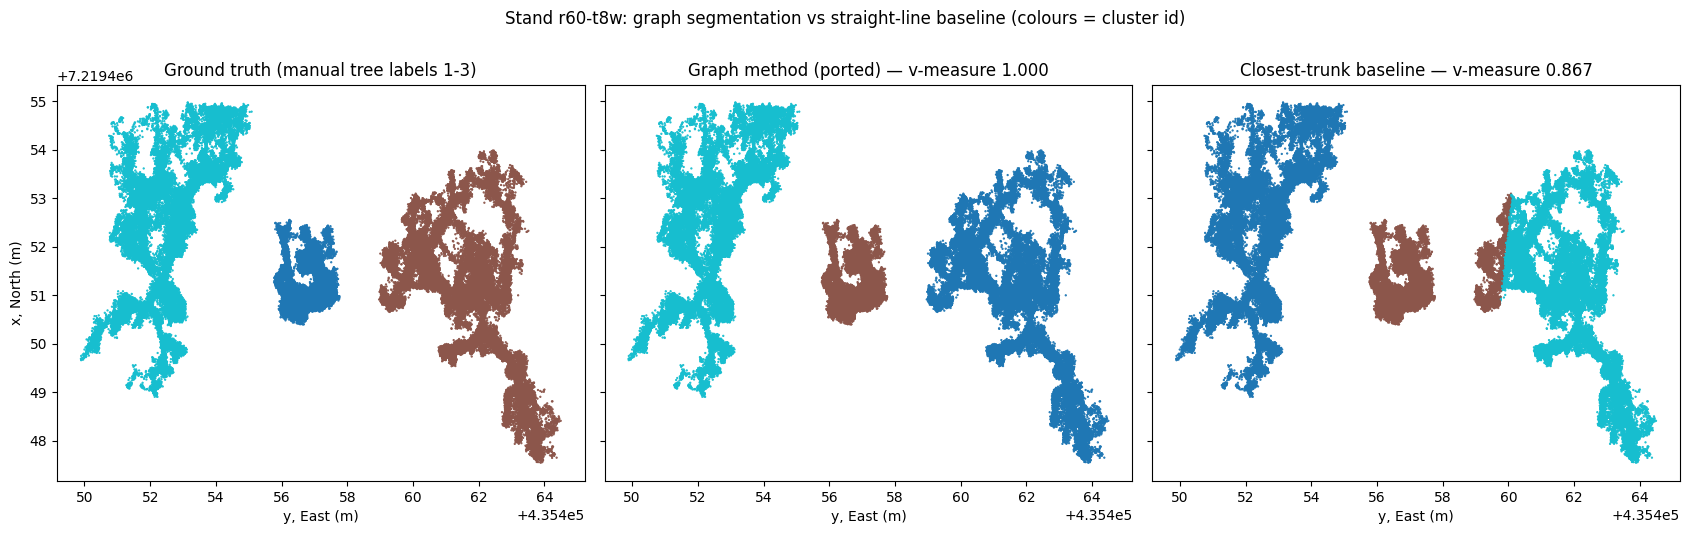

saved /content/gts/segmentation_comparison.png


In [ ]:
import numpy as np, matplotlib.pyplot as plt

em = np.where(eval_mask)[0]
step = max(1, len(em) // 150000)
em = em[::step]
fig, axes = plt.subplots(1, 3, figsize=(17, 5.4), sharex=True, sharey=True)
axes[0].scatter(xyz[em, 1], xyz[em, 0], c=gt[em], s=0.4, cmap="tab10")
axes[0].set_title("Ground truth (manual tree labels 1-3)")
axes[1].scatter(xyz[em, 1], xyz[em, 0], c=seg_pt[em], s=0.4, cmap="tab10")
axes[1].set_title(f"Graph method (ported) — v-measure {vm_graph:.3f}")
axes[2].scatter(xyz[em, 1], xyz[em, 0], c=base_pt[em], s=0.4, cmap="tab10")
axes[2].set_title(f"Closest-trunk baseline — v-measure {vm_base:.3f}")
for ax in axes:
    ax.set_xlabel("y, East (m)")
axes[0].set_ylabel("x, North (m)")
fig.suptitle("Stand r60-t8w: graph segmentation vs straight-line baseline (colours = cluster id)")
fig.tight_layout()
fig.savefig("/content/gts/segmentation_comparison.png", dpi=110, bbox_inches="tight")
plt.show()
print("saved /content/gts/segmentation_comparison.png")

## Interpretation, limitations and references

**What this example shows.** On stand `r60-t8w`, the ported graph operation segments the three
overlapping avocado trees (saved figures and v-measure outputs above come from this executed
run). The graph method's advantage over the straight-line baseline appears exactly where the
paper argues it should: in overlapping canopy, path length *through matter* separates trees that
straight-line distance cannot. One stand is a partial demonstration only — it does not verify
the paper's dataset-level averages (0.915 graph / 0.826 baseline over 40 real stands) nor the
paper's trunk-detection and matter-classification results.

**Fidelity notes (ported from `graph-op` @ `dc9ca8c` + paper Sections 2.2/2.4).**
Voxels w≤1 dropped; non-ground = `height > 0.4` (author script's branch for datasets shipping the
height field; the script's fallback `points-ground height --radius=1` matches the paper's Rg=1 m
local-Z-minima rule); edges within 0.15 m of voxel means with Euclidean cost; trunk→node join
within 0.6 m (=4×radius); per-trunk shortest paths; assignment by minimum path length. The
author script keeps unmatched points at label 0; this port reports them as discarded (-1), and
the baseline is computed on the same evaluated points for a fair comparison. Differences: the
author A* (`graph-search`) and this Dijkstra solve the same single-source shortest-path problem;
`np.add.at`-based voxel averaging replaces `points-to-voxels`; both changes preserve the
paper's stated operations.

**Known limitations.** AI-assisted translation (see disclosure at the top): untested behaviour
beyond this example is not guaranteed. GraphTreeLS carries no LICENSE file — reuse terms must be
checked with the authors before redistribution. The Mendeley record lists no explicit license;
cite the dataset DOI when reusing. The published Elsevier version was not consulted (paywalled);
the arXiv v2 preprint is the verified text.

**References.**
- Westling et al., arXiv:2009.13727v2 (2021-02-02); CEA 187:106270 (2021).
- GraphTreeLS, commit `dc9ca8c7f6518bd90f41df411335014504b5ca17` (files `src/graph-op`, `src/points-ground`, `src/graph-edge`, `src/vmeasure`, `README.md`).
- Dataset: Westling, F. — "Avocado tree point clouds with class labels", Mendeley Data, V1, DOI 10.17632/h49fpprg6c.1.
- Rosenberg & Hirschberg (2007), v-measure; `sklearn.metrics.cluster.v_measure_score`.
日本語：本例は1スタンドの部分実証であり、論文のデータセット全体の平均値の検証ではありません。
AI支援移植であることにご注意ください。